In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rv_continuous, mannwhitneyu
import time

In [33]:
PDF_X = np.linspace(-100, 100, 1000)
trapezoid = np.trapz

In [34]:
class AsymmetricGaussian(rv_continuous):
    """
    Custom Asymmetric Gaussian distribution.
    Use loc for the mean, and unc_minus/unc_plus as shape parameters.
    """
    def _pdf(self, x, unc_minus, unc_plus):
        """x is already shifted by loc internally by scipy"""
        pdf = np.where(
            x < 0,
            np.exp(-0.5 * (x / unc_minus)**2),
            np.exp(-0.5 * (x / unc_plus)**2)
        )
        
        norm = np.sqrt(2 / (np.pi * (unc_plus + unc_minus)**2))
        return norm * pdf

    def _rvs(self, unc_minus, unc_plus, size=None, random_state=None):
        """Generate random samples from the asymmetric Gaussian"""
        rng = np.random.default_rng()
        # Sample from standard normal
        u = rng.standard_normal(size)
        # Map to asymmetric Gaussian: negative values scaled by unc_minus, positive by unc_plus
        samples = np.where(u < 0, u * unc_minus, u * unc_plus)
        return samples

def bc(pdf1, pdf2, x=PDF_X):
    """The bhattacharyya coefficient of PDF1 and PDF2, defined over x"""
    return trapezoid(np.sqrt(pdf1*pdf2), x=x)

def bc_norm_median(mean1, mean2, std1, std2, x=PDF_X):

    reference_pdf = norm.pdf(x, loc=mean1, scale=std1)
    test_pdf = norm.pdf(x, loc=mean2, scale=std2)
    maxtest_pdf = norm.pdf(x, loc=mean1, scale=std2)  

    bc_true = bc(reference_pdf, test_pdf)
    bc_max = bc(reference_pdf, maxtest_pdf)
        
    return bc_true/bc_max

def bc_norm_median_asymmetric(mean1, mean2, std1, unc_minus, unc_plus, x=PDF_X):

    reference_pdf = norm.pdf(x, loc=mean1, scale=std1)
    test_pdf = AsymmetricGaussian().pdf(x, loc=mean2, unc_minus=unc_minus, unc_plus=unc_plus)

    shift_from_mean = (unc_plus-unc_minus)/2
    
    maxtest_pdf = AsymmetricGaussian().pdf(x, loc=mean1-shift_from_mean, unc_minus=unc_minus, unc_plus=unc_plus)  

    bc_true = bc(reference_pdf, test_pdf)
    bc_max = bc(reference_pdf, maxtest_pdf)

    return bc_true/bc_max

def mwu(mean1, mean2, std1, unc_minus, unc_plus, x=PDF_X):

    reference_pdf = norm.pdf(x, loc=mean1, scale=std1)
    test_pdf = AsymmetricGaussian().pdf(x, loc=mean2, unc_minus=unc_minus, unc_plus=unc_plus)

    res = mannwhitneyu(reference_pdf, test_pdf, alternative="two-sided")
    return res.pvalue

def zscore(mean1, mean2, std1, pdf=norm.pdf, *args, **kwargs):
    zscore = (mean2 - mean1) / std1
    return pdf(zscore) / pdf(0)

def resampled_zscore(mean1, mean2, std1, unc_minus, unc_plus, x=PDF_X):
    # Samples 1M values from an asymmetric guassian with the same mean and uncertainty values
    test_rand_values = AsymmetricGaussian().rvs(size=1_000_000, loc=mean2, unc_minus=unc_minus, unc_plus=unc_plus)    
    # Measures the z-scores of all of these values with respect to the provided mean
    resampled_zscores = zscore(mean1, test_rand_values, std1)
    # Returns the median of all of the z-scores
    return np.quantile(resampled_zscores, 0.5)

ag = AsymmetricGaussian()

In [35]:
base_std = 5
base_pdf = ag.pdf(PDF_X, loc=0, unc_minus=base_std, unc_plus=base_std)

test_pdfs = dict(
    base_pdf = dict(loc=0,unc_minus=5, unc_plus=5),
    deltafunc_pdf = dict(loc=0, unc_minus=1, unc_plus=1),
    deltafunc_slightly_offset_pdf = dict(loc=5, unc_minus=1, unc_plus=1),
    deltafunc_offset_pdf = dict(loc=50, unc_minus=1, unc_plus=1),
    wide_pdf = dict(loc=0,unc_minus=10, unc_plus=10),
    wide_pdf_offset = dict(loc=15, unc_minus=10, unc_plus=10),
    wide_pdf_veryoffset = dict(loc=50,unc_minus=10, unc_plus=10),
    verywide_pdf = dict(loc=0,unc_minus=50, unc_plus=50),
    verywide_slightly_offset_pdf = dict(loc=5,unc_minus=50, unc_plus=50),
    verywide_pdf_offset = dict(loc=50,unc_minus=50, unc_plus=50),
    asymmetric_pdf_deltafunc = dict(loc=0, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_deltafunc_offset = dict(loc=50, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_wide = dict(loc=0, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset = dict(loc=50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset_neg = dict(loc=-50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_very_skewed = dict(loc=0, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_offset = dict(loc=20, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_pos = dict(loc=80, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_neg = dict(loc=-80, unc_minus=50, unc_plus=1),
)

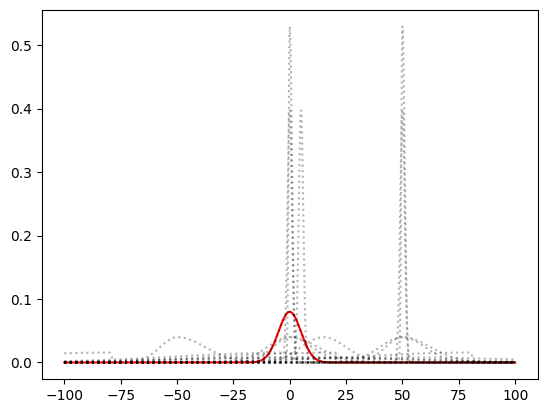

In [36]:
fig, ax = plt.subplots()

ax.plot(PDF_X, base_pdf, color="r")

for label, test_params in test_pdfs.items():
    test = ag.pdf(PDF_X, **test_params)
    ax.plot(PDF_X, test, color="k", alpha=0.3, linestyle=":")

In [37]:
# table = "name,bhattacharyya_coefficient,normalized_bhattacharyya_coefficient,simple_zscore,resampled_zscore\n"

# start = time.perf_counter()

for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)
    norm_bc = bc_norm_median_asymmetric(0, test["loc"], 5, test["unc_minus"], test["unc_plus"])
    mwu_res = mwu(0, test["loc"], 5, test["unc_minus"], test["unc_plus"])
    z = zscore(0, test["loc"], base_std)
    z_resampled = resampled_zscore(0, test["loc"], base_std, test["unc_minus"], test["unc_plus"])
    
    old_bc = bc(base_pdf, test_pdf)
    
    print(label, z, z_resampled)

    # fig, ax = plt.subplots()
    # ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    # ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    # ax.legend()
    # ax.set_title(f"{label}:\nnorm_score={norm_bc:.3f}\nold_score={old_bc:.3f}\nzscore={z:.3f}\nresampled_zscore={z_resampled:.3f}")
    # # fig.savefig(label+".png")

# end = time.perf_counter()
# print(f'Time Elapsed: {end - start}')

base_pdf 1.0 0.7960147713575985
deltafunc_pdf 1.0 0.9909327950193686
deltafunc_slightly_offset_pdf 0.6065306597126334 0.6062656479573478
deltafunc_offset_pdf 1.9287498479639178e-22 1.922908573377045e-22
wide_pdf 1.0 0.4013969789375747
wide_pdf_offset 0.011108996538242306 0.010929391534278191
wide_pdf_veryoffset 1.9287498479639178e-22 1.8269150087240083e-22
verywide_pdf 1.0 1.3429654924302208e-10
verywide_slightly_offset_pdf 0.6065306597126334 9.800019435792329e-11
verywide_pdf_offset 1.9287498479639178e-22 1.2003892596557585e-24
asymmetric_pdf_deltafunc 1.0 0.9957623990589701
asymmetric_pdf_deltafunc_offset 1.9287498479639178e-22 1.920923058395364e-22
asymmetric_pdf_wide 1.0 0.4378857598902929
asymmetric_pdf_wide_offset 1.9287498479639178e-22 1.8928516231357297e-22
asymmetric_pdf_wide_offset_neg 1.9287498479639178e-22 1.9871646125028803e-22
asymmetric_pdf_very_skewed 1.0 0.9138925738218919
asymmetric_pdf_very_skewed_offset 0.00033546262790251185 0.00021521420026342252
asymmetric_pdf_ve

In [38]:
# Self-Entropy
# Sum of -p_i*log(p_i)
# Add a minimum bound to prevent log(0) errors

def shannon_entropy(pdf, eps=1e-85):
    pdf = np.asarray(pdf, dtype=float)
    # Normalization
    pdf = pdf / np.sum(pdf)
    pdf = np.clip(pdf, eps, None)
    return float(np.sum(-pdf * np.log2(pdf)))

# Relative Entropy Calculations
# D(P || Q) = sum_i p_i * log2(p_i / q_i)
# This is non-negative when both inputs are valid probability distributions.
def relative_entropy(p, q, eps=1e-85):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if p.shape != q.shape:
        raise ValueError("p and q must have the same shape")

    p = p / np.sum(p)
    q = q / np.sum(q)

    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)

    return float(np.sum(p * np.log2(p / q)))

# JSD (Jensen-Shannon Divergence)
# JSD(P || Q) = 0.5 * D(P || M) + 0.5 * D(Q || M)
# where M = 0.5 * (P + Q). With base-2 logs, JSD is bounded between 0 and 1.
# 0 means that the distributions are very similar, and 1 means that they are completely different
def jsd(p, q, eps=1e-85):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Normalization of PDFs
    p = p / np.sum(p)
    q = q / np.sum(q)

    m = 0.5 * (p + q)
    jsd_value = 0.5 * relative_entropy(p, m, eps=eps) + 0.5 * relative_entropy(q, m, eps=eps)
    return float(jsd_value)

# Consider a better way to measure how uniform the function is
# Current problem is that heavily skewed PDFs are getting a very low score in compare uniform
# even though they are fairly well-known, and this is inflating the asymmetric_pdf_skewed scores
def compare_uniform(p, eps=1e-15):
    # Instead of naively generating the uniform distribution across p's entire domain
    # only generate uniform_dist across the region where p > eps
    uniform_dist = np.full_like(p, 1.0 / len(p))
    return jsd(uniform_dist, p)

# This is not really giving very good results
# Entropy comparison to uniform distribution
def entropy_comp_uniform(p):
    # np.log2(len(p)) is the entropy of a completely uniform distribution
    return 1 - (shannon_entropy(p) / np.log2(len(p)))

def raw_zscore(mean1, mean2, std):
    return (mean2 - mean1) / std

In [39]:
# Not sure if this is a meaningful metric because of arbitrary normalization
import numpy as np
from scipy.stats import wasserstein_distance

def get_alignment_score(x_grid, p, q):
    # Measures how much "work" is required to transform q --> p
    # by measuring the probability mass and the distance it must travel
    # Learn some more detail about exactly how this works mathematically
    emd = wasserstein_distance(x_grid, x_grid, u_weights=p, v_weights=q)
    
    max_dist = x_grid[-1] - x_grid[0] 
    
    raw_score = 1.0 - (emd / max_dist)
    
    # Optional: Apply a non-linear power curve to penalize offsets aggressively
    return raw_score ** 2

In [48]:
# start = time.perf_counter()
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)
    
    z_score = raw_zscore(0, test['loc'], base_std)

    # 0 --> Close to each other
    # 1 --> Far from each other
    jsd_val = jsd(test_pdf, base_pdf)
    # 0 --> Close to uniform 
    # 1 --> Far from uniform
    uni_comp = compare_uniform(test_pdf)

    # With this product, if test_pdf is very close to uniform distribution
    # then its final_score will be near 1, so the jsd_val does not impact this significantly
    # However, if the distribution is far from uniform, then uni_comp is near 1, so the final
    # score is completely dependent on the JSD val
    # Consider non-linear final score calculations as well

    # Currently, information theory metrics alone does not give any information
    # about alignment or spatial relations, so we need to combine these
    # The main problem is coming from delta functions, which are localized at the mean of the 
    # target distribution, but because they don't have the target distribution shape, they are 
    # getting penalized for it
    # Prioritize alignment score, fine_tune these weights
    inform_score = 1 - (jsd_val)
    zscored = zscore(0, test['loc'], base_std)

    # Conditional Scoring
    if uni_comp < 0.2:
        # Should this just be 1 or some small deviation?
        # No small deviation because if uni_comp is that low, then we don't know anything about
        # the function
        final_score = 1 - uni_comp
    elif abs(z_score) < 0.3:
        # Consider introducing a little bit more information about how the distribution matches the target
        # Currently losing a bit too much
        final_score = 0.95*(zscored) + 0.05*(inform_score)
    else:
        final_score = 0.9*inform_score + 0.1*zscored

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"out/jsd_uniform/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

# end = time.perf_counter()
# print(f'Time Elapsed: {end - start}')

# Think about how to improve these metrics such that plots like asymmetric delta_func and asymmetric very skewed still have very high scores
# Essentially, we don't necessarily want to measure the overlap of the PDFs, what we want to actually measure is whether the 2 PDFs peak 
# at the same place? 

# We could also consider a discrete type of scoring method with conditionals
# For example, if the JSD_Uniform is below a certain threshold, than the score is automatically one
# If the Z-Score is within a certain range, then the z-score should be the only thing determining the score
# If these 2 criteria are not satisfied, then use a naive implementation of 1 - (uni_comp * jsd_val)

# This method relies on tunable parameters like the thresholds

In [41]:
# Not good results
# Delta function getting uniform score of 0.6, should be much closer to 1
# for label, test in test_pdfs.items():
#     test_pdf = ag.pdf(PDF_X, **test)

#     # Normalization
#     test_pdf = test_pdf / np.sum(test_pdf)
#     base_pdf = base_pdf / np.sum(base_pdf)

#     # 0 --> Close to each other
#     # 1 --> Far from each other
#     jsd_val = jsd(test_pdf, base_pdf)
#     # 0 --> Close to uniform
#     # 1 --> Far from uniform
#     uni_comp = entropy_comp_uniform(test_pdf)

#     # With this product, if test_pdf is very close to uniform distribution
#     # then its final_score will be near 1, so the jsd_val does not impact this significantly
#     # However, if the distribution is far from uniform, then uni_comp is near 1, so the final
#     # score is completely dependent on the JSD val
#     final_score = 1 - (uni_comp * jsd_val)

#     fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
#     ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
#     ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
#     ax.legend()
#     ax.set_title(f"{label}\nJSD Val: {jsd_val}\nUniform Comparison: {uni_comp}\n Final Score: {final_score}", pad=12)
#     fig.savefig(f"out/entropy_uniform/{label}.png", dpi=300, bbox_inches="tight")
#     plt.close(fig)